In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import time

In [2]:
X, y = make_classification(n_samples=100000, n_features=20, n_informative=14, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=42)
start = time.time()
clf.fit(X_train,y_train)
end = time.time()
print("Training time: ", end - start)


clf = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=42, n_jobs=-1)
start = time.time()
clf.fit(X_train,y_train)
end = time.time()
print("Training time: ", end - start)

Training time:  5.638402223587036
Training time:  0.8226108551025391


Training time with  1  cores:  5.553637981414795
Training time with  2  cores:  2.844788074493408
Training time with  3  cores:  1.954805850982666
Training time with  4  cores:  1.4818618297576904
Training time with  5  cores:  1.1854300498962402
Training time with  6  cores:  1.0172958374023438
Training time with  7  cores:  0.918881893157959
Training time with  8  cores:  0.8830320835113525
Training time with  9  cores:  0.7845680713653564
Training time with  10  cores:  0.824127197265625


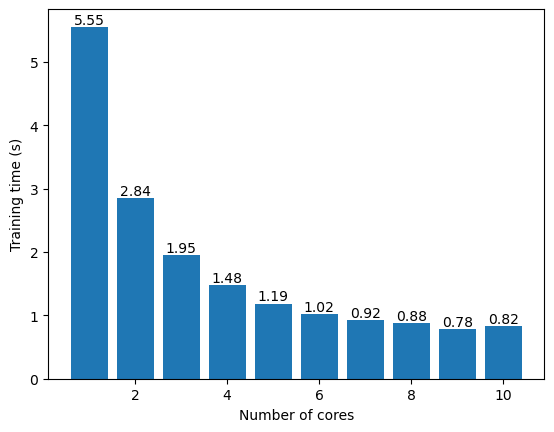

In [5]:
# evaluate the running time of the model as a function of the number of cores (1 to 10)
times = []
for i in range(1,11):
    clf = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=42, n_jobs=i)
    start = time.time()
    clf.fit(X_train,y_train)
    end = time.time()
    times.append(end - start)
    print("Training time with ", i, " cores: ", end - start)

# plot the running time as a function of the number of cores
import matplotlib.pyplot as plt
plt.bar(range(1,11), times)
# show values on top of bars
for i in range(10):
    plt.text(i+1, times[i], round(times[i],2), ha='center', va='bottom')
plt.xlabel("Number of cores")
plt.ylabel("Training time (s)")
plt.show()

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=6, random_state=1)
start = time.time()
n_scores = cross_val_score(clf, X, y, scoring='accuracy', cv=cv)
end = time.time()
print("Training time: ", end - start)

start = time.time()
n_scores = cross_val_score(clf, X, y, scoring='accuracy', cv=cv,n_jobs=-1)
end = time.time()
print("Training time: ", end - start)

Training time:  64.08452725410461
Training time:  50.227174043655396
